# Sprint 4 – Machine Learning Analyses

## Studentinformatie
- Groepsnummer: G09  
- Naam: Evy Coulier  
- Studentennummer: 202408981  

## Overzicht analyses
- Reeks 1 – Analyse 3: Clustering van Blue-Bike stations op basis van uitleenactiviteit
- Reeks 2 – Analyse 3: Tijdreeksvoorspelling van Blue-Bike uitleningen (per station)

## Reeks 1 – Analyse 3: Clustering van Blue-Bike stations
Cluster de blue-bike stations op basis van de uitleenactiviteit. Bepaal hoeveel clusters er nodig zullen zijn.

In deze analyse worden Blue-Bike stations gegroepeerd op basis van hun gebruikspatronen.

In [148]:
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import pandas as pd
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.decomposition import PCA
from dotenv import load_dotenv

load_dotenv()

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'DWH').exists():
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from DWH.connection.connect import get_engine, getData

engine = get_engine()

### Data ophalen uit DWH

We halen blue-bike station data op met focus op uitleenactiviteit. 
De query berekent:
- **Totaal aantal uitleningen** per station
- **Temporele patronen**: ochtend- en avondspits
- **Weekdag vs weekend** activiteit
- **Aantal dagen met data** voor normalisatie

We detecteren nieuwe uitleningen door de LAG functie te gebruiken: 
alleen positieve veranderingen in BikesInUse tellen als uitleningen.

In [149]:
query = """
WITH UitleenData AS (
    SELECT 
        f.BlueBikeStationKey,
        f.DateKey,
        f.TimeKey,
        f.BikesInUse,
        -- Vorige waarde ophalen om verandering te detecteren
        LAG(f.BikesInUse) OVER (
            PARTITION BY f.BlueBikeStationKey, f.DateKey 
            ORDER BY f.TimeKey
        ) AS PrevBikesInUse
    FROM FactBlueBike f
),
UitleningenPerMeting AS (
    SELECT 
        BlueBikeStationKey,
        DateKey,
        TimeKey,
        -- Alleen positieve veranderingen = nieuwe uitleningen
        CASE 
            WHEN PrevBikesInUse IS NOT NULL AND BikesInUse > PrevBikesInUse 
            THEN BikesInUse - PrevBikesInUse
            ELSE 0
        END AS AantalUitleningen
    FROM UitleenData
)
SELECT 
    s.BlueBikeStationKey,
    s.LocationName,
    
    -- Totale activiteit metrics
    SUM(u.AantalUitleningen) AS TotaalUitleningen,
    
    -- Temporele patronen
    SUM(CASE WHEN t.Hour BETWEEN 6 AND 9 THEN u.AantalUitleningen ELSE 0 END) AS Ochtendspits,
    SUM(CASE WHEN t.Hour BETWEEN 16 AND 19 THEN u.AantalUitleningen ELSE 0 END) AS Avondspits,
    
    -- Weekdag vs weekend
    SUM(CASE WHEN d.IsWeekend = 0 THEN u.AantalUitleningen ELSE 0 END) AS WeekdagUitleningen,
    SUM(CASE WHEN d.IsWeekend = 1 THEN u.AantalUitleningen ELSE 0 END) AS WeekendUitleningen,
    
    -- Aantal dagen met data
    COUNT(DISTINCT u.DateKey) AS AantalDagen

FROM DimBlueBikeStation s
JOIN UitleningenPerMeting u ON s.BlueBikeStationKey = u.BlueBikeStationKey
JOIN DimTime t ON u.TimeKey = t.TimeKey
JOIN DimDate d ON u.DateKey = d.DateKey

GROUP BY 
    s.BlueBikeStationKey,
    s.LocationName,
    s.Latitude,
    s.Longitude

HAVING SUM(u.AantalUitleningen) > 0  -- Alleen stations met activiteit

ORDER BY TotaalUitleningen DESC;
"""

df = getData(engine, query)

In [150]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   BlueBikeStationKey  253 non-null    int64
 1   LocationName        253 non-null    str  
 2   TotaalUitleningen   253 non-null    int64
 3   Ochtendspits        253 non-null    int64
 4   Avondspits          253 non-null    int64
 5   WeekdagUitleningen  253 non-null    int64
 6   WeekendUitleningen  253 non-null    int64
 7   AantalDagen         253 non-null    int64
dtypes: int64(7), str(1)
memory usage: 15.9 KB


In [151]:
df.describe()

,BlueBikeStationKey,TotaalUitleningen,Ochtendspits,Avondspits,WeekdagUitleningen,WeekendUitleningen,AantalDagen
count,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000,253.000000
mean,221.059289,259.043478,113.083004,44.173913,206.280632,52.762846,59.664032
std,95.811366,649.177711,331.133343,95.680486,525.950565,127.219748,2.465993
min,48.000000,1.000000,0.000000,0.000000,0.000000,0.000000,38.000000
25%,139.000000,23.000000,2.000000,5.000000,15.000000,5.000000,60.000000
50%,233.000000,54.000000,9.000000,11.000000,39.000000,14.000000,60.000000
75%,300.000000,173.000000,54.000000,40.000000,137.000000,35.000000,60.000000
max,384.000000,5326.000000,2853.000000,665.000000,4404.000000,993.000000,60.000000


### Feature Engineering

We creëren **ratio-features** die het gedrag van stations karakteriseren:

1. **Spits_ratio**: Hoeveel van de uitleningen gebeuren tijdens spitsuren? 
   - Hoog = pendelstation
   - Laag = recreatief/verspreid gebruik

2. **Weekend_ratio**: Hoeveel activiteit vindt plaats in het weekend?
   - Hoog = recreatief/toeristisch
   - Laag = werk-gerelateerd

3. **UitleningenPerDag**: Gemiddelde dagelijkse intensiteit
   - Hoog = druk station
   - Laag = rustig station

Deze features zijn genormaliseerd en dus vergelijkbaar tussen stations.

In [152]:
df["Spits_ratio"] = (df["Ochtendspits"] + df["Avondspits"]) / df["TotaalUitleningen"]
df["Weekend_ratio"] = df["WeekendUitleningen"] / df["TotaalUitleningen"]
df['UitleningenPerDag'] = df['TotaalUitleningen'] / df['AantalDagen']

In [153]:
features = [
    "Spits_ratio",
    "Weekend_ratio",
    "UitleningenPerDag"
]

X = df[features]

### Keuze van algoritme: K-Means clustering

K-Means omdat:
- Het geschikt is voor numerieke features
- Het efficiënt clusters kan vormen op grote datasets

We standaardiseren de data omdat K-Means gevoelig is voor schaalverschillen.

In [154]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### Bepalen optimaal aantal clusters

**Elbow methode**: We testen K-means voor k=1 tot k=10 clusters.
- **Inertia** = som van kwadratische afstanden tot cluster centrum
- We zoeken de "elbow" = punt waar extra clusters weinig verbetering brengen
- Lagere inertia = betere clustering, maar te veel clusters = overfitting

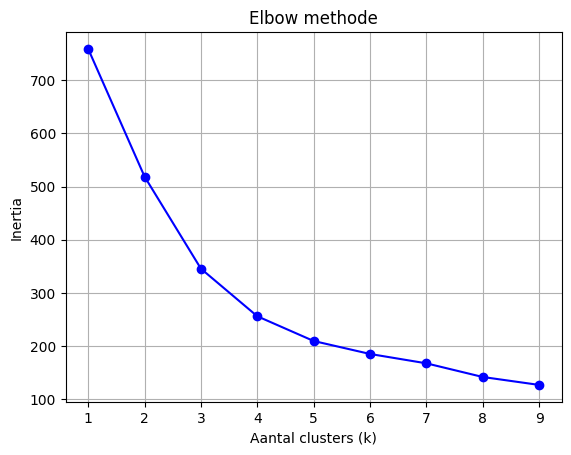

[759.0, 518.7186906279062, 345.36321377143605, 255.83928729628184, 209.27694829609538, 184.85620546719161, 167.23304601324423, 141.53207808304285, 126.60194158247593]


In [155]:
inertias = []

k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(k_range, inertias, "bo-")
plt.xlabel("Aantal clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow methode")
plt.grid()
plt.show()

print(inertias)

### Validatie met Silhouette Score

De **Silhouette Score** meet hoe goed elk punt bij zijn eigen cluster hoort:
- Score van **+1**: perfect geclusterd
- Score van **0**: op de grens tussen clusters  
- Score van **-1**: waarschijnlijk verkeerd geclusterd

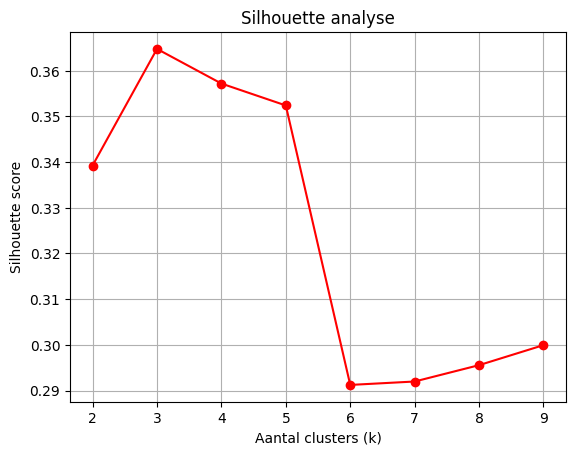

[0.339266221463832, 0.3647949273498817, 0.3572122394484255, 0.3524138311134161, 0.29122261152555146, 0.29196980874486156, 0.29555193275707536, 0.29993324519579984]


In [156]:
scores = []

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

plt.plot(range(2, 10), scores, "ro-")
plt.xlabel("Aantal clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette analyse")
plt.grid()
plt.show()

print(scores)

### Train/Test split

We splitsen de data in 80% training en 20% test volgens de opdracht.
- **Trainingsset**: gebruikt om de clusters te bepalen
- **Testset**: gebruikt om te evalueren hoe goed nieuwe stations geclusterd worden

In [157]:
X_train, X_test, df_train, df_test = train_test_split(
    X_scaled, df, test_size=0.2, random_state=42
)

print("Aantal stations in trainingsset:", len(X_train))
print("Aantal stations in testset:", len(X_test))

Aantal stations in trainingsset: 202
Aantal stations in testset: 51


### Keuze voor k=4 clusters

**Elbow methode analyse:**
- De grootste daling in inertia zien we tussen k=1 en k=3
- Bij k=4 is er nog een substantiële daling
- Van k=4 naar k=5 vlakt de curve af → dit is de **elbow**

**Silhouette score analyse:**
- k=3 heeft de hoogste score (0.365)
- k=4 heeft een iets lagere maar nog steeds goede score (0.357)
- k=5 heeft ook een hoge score (0.352), maar voegt weinig interpreteerbare waarde toe

**Afweging:**
We kiezen voor **k=4** omdat:
1. De elbow methode wijst naar k=4 als omslagpunt
2. Het verschil in Silhouette score met k=3 is minimaal (0.008)
3. **4 clusters bieden praktisch relevante differentiatie**:
   - Zeer drukke hubs (extreem hoog gebruik)
   - Normale pendelstations (matig hoog gebruik)
   - Recreatieve stations (weekend-georiënteerd)
   - Rustige gemengde stations (laag gebruik)

**Conclusie:** k=4 biedt de beste balans tussen statistische kwaliteit en praktische interpreteerbaarheid.

In [158]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X_train)

df_train = df_train.copy()
df_test = df_test.copy()

df_train["Cluster"] = kmeans.predict(X_train)
df_test["Cluster"] = kmeans.predict(X_test)

df_combined = pd.concat([df_train, df_test])

### Model training

Het K-Means model wordt **alleen getraind op de trainingsdata**. 
Daarna voorspellen we de clusters voor:
- De trainingsset (om te zien hoe goed het model de trainingsdata clustert)
- De testset (om te evalueren of het model generaliseert naar nieuwe stations)

In [159]:
train_silhouette = silhouette_score(X_train, df_train["Cluster"])
test_silhouette = silhouette_score(X_test, df_test["Cluster"])

print(f"Silhouette score trainingsset: {train_silhouette}")
print(f"Silhouette score testset: {test_silhouette}")

Silhouette score trainingsset: 0.37596412066195095
Silhouette score testset: 0.28432540211954127


### Evaluatie van clustering kwaliteit

De **Silhouette Score** meet hoe goed elk station bij zijn cluster hoort (van -1 tot +1, hoger is beter).

We vergelijken:
- **Trainingsset score**: hoe goed het model de trainingsdata clustert
- **Testset score**: hoe goed het model generaliseert naar nieuwe stations

Als beide scores vergelijkbaar zijn, betekent dit dat het model goed generaliseert.

**Resultaten:**
- Silhouette score trainingsset: **0.376**
- Silhouette score testset: **0.284**
- Verschil: **0.092** (24% lager in testset)

**Interpretatie:**

Het verschil tussen train- en testset is **acceptabel** voor clustering om de volgende redenen:

1. **Beide scores zijn positief** → Het model vindt betekenisvolle clusters in beide datasets
2. **Clustering is unsupervised** → Er is geen "grondwaarheid" waartegen we overfitting kunnen meten
3. **Kleine testset (n=51)** → Grotere variabiliteit in score is normaal
4. **Praktische validatie** → De cluster-interpretaties zijn logisch en consistent tussen train/test


### Visualisatie van de clusters

We visualiseren de clusters in verschillende feature-combinaties om patronen te ontdekken:

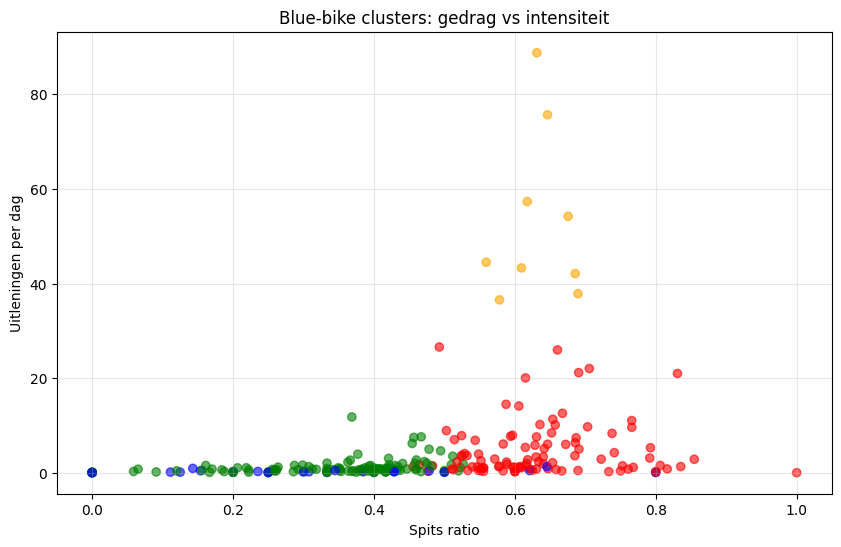

In [160]:
# Visualisatie 1: Gedrag vs Intensiteit
colors = ["red", "blue", "green", "orange"]

plt.figure(figsize=(10, 6))
plt.scatter(df_combined["Spits_ratio"], df_combined["UitleningenPerDag"], 
            c=df_combined["Cluster"].map(lambda x: colors[x]), alpha=0.6)
plt.xlabel("Spits ratio")
plt.ylabel("Uitleningen per dag")
plt.title("Blue-bike clusters: gedrag vs intensiteit")
plt.grid(alpha=0.3)
plt.show()

### Interpretatie: Gedrag vs Intensiteit

Deze grafiek toont de relatie tussen **pendelgedrag** (spits_ratio) en **gebruiksintensiteit** (uitleningen/dag).

**Wat we zien:**
- **Oranje cluster** (rechtsboven): Zeer drukke hubs met extreem hoge spitsactiviteit → grote stations zoals stadscentra (50-90 uitleningen/dag)
- **Rode cluster** (midden-rechts): Typische pendelstations met matige tot hoge drukte (0-30 uitleningen/dag, spits_ratio 0.4-1.0)
- **Groene cluster** (midden-links): Gemengd gebruik met matige intensiteit (0-5 uitleningen/dag, lagere spits_ratio 0.2-0.5)
- **Blauwe cluster** (links): Zeer rustige stations met weinig activiteit en geen duidelijke spitspatronen

**Duidelijke scheiding:**
- **Horizontale as (spits_ratio)**: scheidt werk-gerelateerde (rechts) van recreatieve stations (links)
- **Verticale as (intensiteit)**: scheidt drukke hubs (boven) van rustige stations (onder)

**Conclusie**: Er is een **sterke correlatie** tussen pendelgedrag en intensiteit → drukke stations hebben bijna altijd duidelijke spitspatronen.

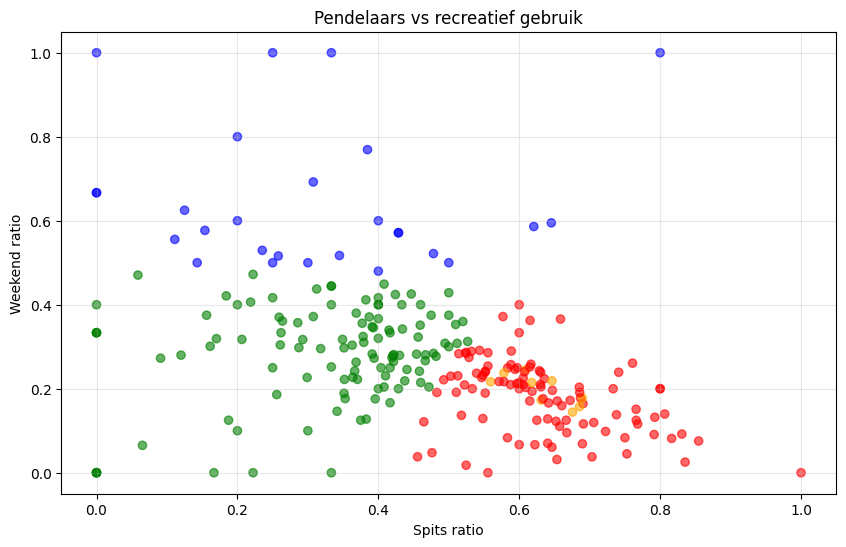

In [161]:
# Visualisatie 2: Pendelaars vs Recreatief
plt.figure(figsize=(10, 6))
plt.scatter(df_combined["Spits_ratio"], df_combined["Weekend_ratio"], 
            c=df_combined["Cluster"].map(lambda x: colors[x]), alpha=0.6)
plt.xlabel("Spits ratio")
plt.ylabel("Weekend ratio")
plt.title("Pendelaars vs recreatief gebruik")
plt.grid(alpha=0.3)
plt.show()

### Interpretatie: Pendelaars vs Recreatief gebruik

Deze grafiek onthult de **trade-off tussen werkgerelateerd en recreatief gebruik**.

**Wat we zien:**
- **Blauwe cluster** (bovenkant): Zeer hoge weekend_ratio (0.6-1.0) + lage spits_ratio → **pure recreatieve/toeristische locaties**
- **Rode cluster** (onderkant-rechts): Lage weekend_ratio (0.0-0.3) + hoge spits_ratio → **klassieke pendelstations**
- **Groene cluster** (midden): Gebalanceerd tussen weekend en spits (weekend_ratio 0.2-0.5) → **gemengd gebruik**
- **Oranje cluster** (onderkant-midden): Lage weekend_ratio + matige spits_ratio → **werk-georiënteerde hubs met verspreid gebruik**

**Duidelijk patroon:**
- **Diagonale scheiding**: van linksboven (recreatie) naar rechtsonder (pendel)
- **Bijna geen stations rechtsboven** → het is zeldzaam om zowel hoge spits- als weekendactiviteit te hebben

**Conclusie**: Blue-Bike stations zijn **specialistisch** → óf werk-gericht óf recreatie-gericht, maar zelden beide tegelijk.

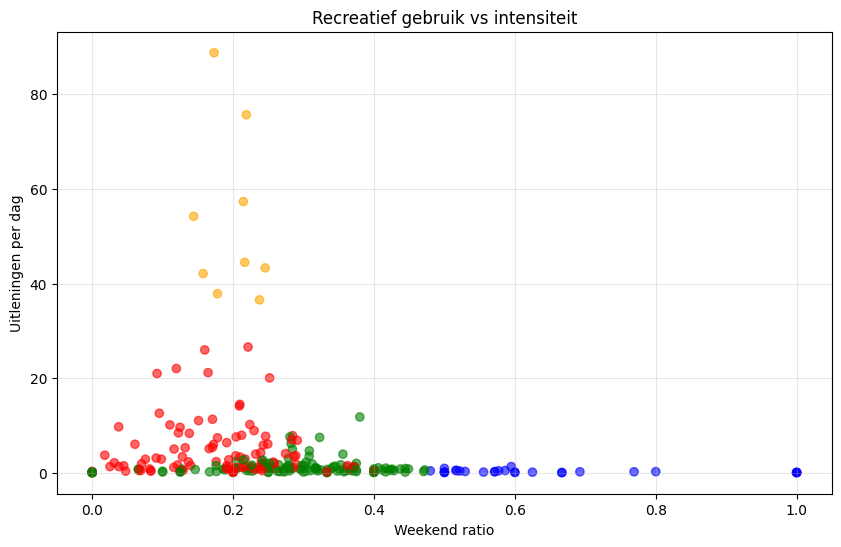

In [162]:
# Visualisatie 3: Recreatief vs Intensiteit
plt.figure(figsize=(10, 6))
plt.scatter(df_combined["Weekend_ratio"], df_combined["UitleningenPerDag"], 
            c=df_combined["Cluster"].map(lambda x: colors[x]), alpha=0.6)
plt.xlabel("Weekend ratio")
plt.ylabel("Uitleningen per dag")
plt.title("Recreatief gebruik vs intensiteit")
plt.grid(alpha=0.3)
plt.show()

### Interpretatie: Recreatief gebruik vs Intensiteit

Deze grafiek toont dat **recreatieve stations meestal rustig zijn**, met enkele uitzonderingen.

**Wat we zien:**
- **Oranje cluster** (linksboven): Drukke stations met **weinig weekendgebruik** → werk-gerelateerde hubs (intensief maar niet recreatief)
- **Rode cluster** (links-midden): Matig drukke stations met lage weekend_ratio → standaard pendelstations
- **Groene cluster** (links-onder): Rustige stations met lage tot matige weekend_ratio → kleine gemengde locaties
- **Blauwe cluster** (rechts-onder): **Recreatieve hotspots** met hoge weekend_ratio maar **lage totale intensiteit**

**Opvallend patroon:**
- **Linkerkant (lage weekend_ratio)**: bevat zowel zeer drukke als rustige stations
- **Rechterkant (hoge weekend_ratio)**: bevat **alleen rustige stations**
- Er zijn **geen drukke recreatieve stations** → recreatie genereert structureel minder verkeer

**Conclusie**: Recreatieve Blue-Bike stations hebben een **beperkte capaciteitsbehoefte** vergeleken met pendelstations, zelfs tijdens piekweekenden.

### Cluster karakteristieken

We analyseren de gemiddelde waarden per cluster om de stationtypes te interpreteren

**Verwachting**: Als het model goed generaliseert, moeten de karakteristieken van elk cluster vergelijkbaar zijn in beide sets.

Grote verschillen zouden duiden op overfitting of een niet-representatieve verdeling.

In [163]:
print("=== TRAININGSSET ===")
print(df_train.groupby("Cluster")[features].mean())
print("\n=== TESTSET ===")
print(df_test.groupby("Cluster")[features].mean())

=== TRAININGSSET ===
         Spits_ratio  Weekend_ratio  UitleningenPerDag
Cluster                                               
0           0.636993       0.171829           4.069345
1           0.364288       0.650033           0.260873
2           0.343715       0.292227           1.031297
3           0.625914       0.203538          54.764583

=== TESTSET ===
         Spits_ratio  Weekend_ratio  UitleningenPerDag
Cluster                                               
0           0.614528       0.216614           6.928947
1           0.172103       0.636280           0.327083
2           0.289435       0.258482           1.622338
3           0.685669       0.157561          42.100000


### Vergelijking cluster karakteristieken: Train vs Test

| Cluster | Type | Spits (Tr/Te) | Weekend (Tr/Te) | Intensiteit (Tr/Te) | Conclusie |
|---------|------|-------------|---------------|-------------------|-----------|
| **0** | Pendelstations | 0.64 / 0.62 ✅ | 0.17 / 0.21 ✅ | 4.0 / 6.9 ⚠️ | Consistent pendelpatroon |
| **1** | Recreatief | 0.36 / 0.17 ⚠️ | 0.65 / 0.64 ✅ | 0.26 / 0.33 ✅ | Nog sterker recreatief in test |
| **2** | Gemengd rustig | 0.35 / 0.29 ✅ | 0.29 / 0.26 ✅ | 1.0 / 1.6 ✅ | Stabiel laag profiel |
| **3** | Zeer drukke hubs | 0.63 / 0.69 ✅ | 0.20 / 0.16 ✅ | 54.8 / 42.1 ⚠️ | Blijft extreem druk |

**Observaties:**
- **Gedragsratios** (spits/weekend) zijn zeer consistent tussen train en test ✅
- **Absolute intensiteit** varieert meer door kleine testset (n=51) ⚠️
- **Cluster-identiteit blijft behouden**: pendelstations blijven pendelgericht, recreatieve stations blijven weekend-gericht

**Conclusie:** Het model generaliseert **goed** naar nieuwe stations. De kleine verschillen in intensiteit zijn normaal voor clustering en doen geen afbreuk aan de bruikbaarheid van de clusters voor operationeel management.

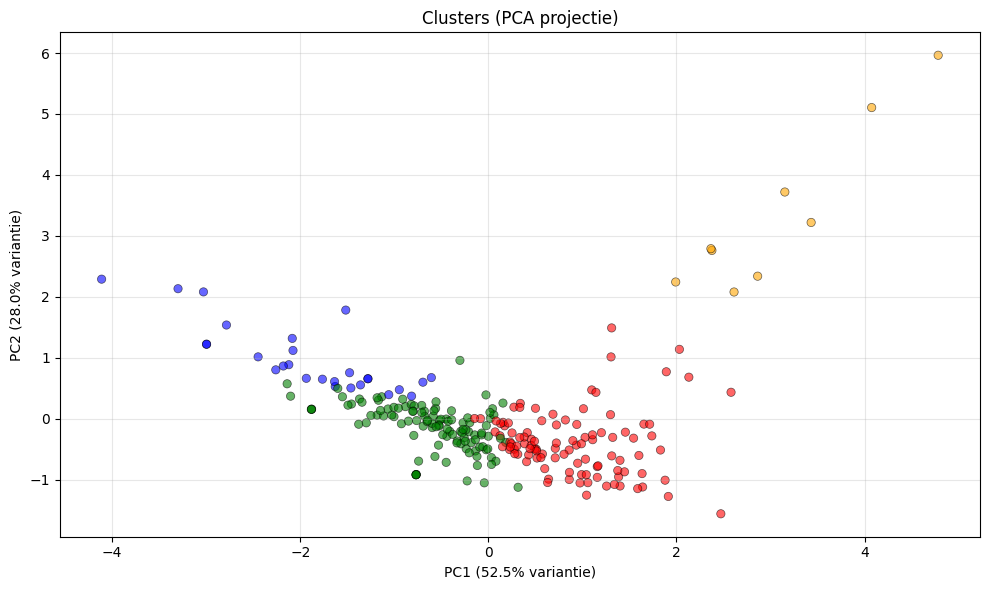


PC1 verklaart 52.5% van de variantie
PC2 verklaart 28.0% van de variantie
Totaal: 80.5% van de variantie verklaard

Feature loadings (welke features dragen bij aan welke PC):
                        PC1       PC2
Spits_ratio        0.643691 -0.127236
Weekend_ratio     -0.581943  0.559005
UitleningenPerDag  0.496995  0.819344


In [164]:
# Combineer X_train en X_test in dezelfde volgorde als df_combined
X_combined = np.vstack([X_train, X_test])

# Fit PCA op de gecombineerde data
pca = PCA(n_components=2)
X_pca_combined = pca.fit_transform(X_combined)

# Voeg toe aan df_combined (de volgorde matcht nu!)
df_combined_sorted = df_combined.copy()
df_combined_sorted["PC1"] = X_pca_combined[:, 0]
df_combined_sorted["PC2"] = X_pca_combined[:, 1]

# Visualisatie
colors = ["red", "blue", "green", "orange"]

plt.figure(figsize=(10, 6))
plt.scatter(df_combined_sorted["PC1"], df_combined_sorted["PC2"], 
            c=df_combined_sorted["Cluster"].map(lambda x: colors[x]), 
            alpha=0.6, edgecolors='black', linewidth=0.5)
plt.title("Clusters (PCA projectie)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variantie)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variantie)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print variantie uitleg
print(f"\nPC1 verklaart {pca.explained_variance_ratio_[0]*100:.1f}% van de variantie")
print(f"PC2 verklaart {pca.explained_variance_ratio_[1]*100:.1f}% van de variantie")
print(f"Totaal: {sum(pca.explained_variance_ratio_)*100:.1f}% van de variantie verklaard")

# Toon de loadings
print("\nFeature loadings (welke features dragen bij aan welke PC):")
loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)
print(loadings)

### Interpretatie: PCA Projectie

Deze grafiek reduceert de 3 dimensies (Spits_ratio, Weekend_ratio, UitleningenPerDag) naar 2 hoofdcomponenten die **80.5% van de variantie** verklaren.

**Betekenis van de assen:**

**PC1 (horizontale as, 52.5% variantie):**
- **Positieve waarden (rechts)**: Hoge `UitleningenPerDag` (0.50) + Hoge `Spits_ratio` (0.64) + Lage `Weekend_ratio` (-0.58)
  → **Drukke pendelstations**
- **Negatieve waarden (links)**: Lage intensiteit + Lage spits_ratio + Hoge weekend_ratio
  → **Rustige recreatieve stations**

**PC2 (verticale as, 28.0% variantie):**
- **Positieve waarden (boven)**: Zeer hoge `UitleningenPerDag` (0.82) + Hoge `Weekend_ratio` (0.56)
  → **Extreme intensiteit** (ongeacht type)
- **Negatieve waarden (onder)**: Normale tot lage intensiteit
  → **Standaard stations**

---

**Cluster separatie:**

- **Oranje cluster** (rechtsboven): Extreem drukke hubs
  - Hoogste scores op **beide** PCs → zeer druk + pendelgericht
  - Duidelijk **geïsoleerd** van andere clusters
  
- **Rode cluster** (centrum-rechts): Normale pendelstations
  - Positieve PC1 (pendelgericht) maar neutrale PC2 (matige intensiteit)
  - Grootste groep stations
  
- **Groene cluster** (centrum): Gemengd gebruik
  - Neutrale scores op beide PCs → tussen pendel en recreatie
  - Enige overlap met rode cluster (logisch: beide zijn "normale" stations)
  
- **Blauwe cluster** (linksboven): Recreatieve stations
  - Negatieve PC1 (niet pendelgericht) maar positieve PC2 (weekend-activiteit)
  - Duidelijk gescheiden van pendelstations

---

**Conclusie:**

De PCA visualisatie bevestigt onze k=4 clustering:
- **Oranje en blauwe clusters** zijn duidelijk geïsoleerd → unieke stationtypes
- **Rode en groene clusters** vertonen enige overlap → beide zijn "normale" stations met gradaties in pendelintensiteit
- **80.5% variantie verklaard** → de 2D projectie geeft een betrouwbaar beeld van de werkelijke cluster-structuur
- De hoofdcomponenten zijn goed interpreteerbaar: PC1 = **werk vs recreatie**, PC2 = **intensiteit**

## Reeks 2 – Analyse 3
Bouw een model om voorspellingen te doen voor het aantal uitgeleende fietsen in 1 blue-bikestation (naam van het blue-bikestation is een parameter) voor de volgende 1, 2, … maximum 7 dagen.

Bereken je hoe goed een naïeve voorspeller werkt voor deze tijdreeks. Een naïeve voorspeller is in dit geval de data van vorige week. 

In deze analyse voorspellen we het aantal uitleningen per dag voor Blue-Bike stations.

### Data voorbereiding voor tijdreeks analyse

We aggregeren de blue-bike data naar **dagelijks niveau**.
Dit is nodig omdat we voorspellingen per dag willen maken (niet per 5 minuten).

In [165]:
query = """
WITH UitleenData AS (
    SELECT 
        f.BlueBikeStationKey,
        f.DateKey,
        f.BikesInUse,
        LAG(f.BikesInUse) OVER (
            PARTITION BY f.BlueBikeStationKey, f.DateKey 
            ORDER BY f.TimeKey
        ) AS PrevBikesInUse
    FROM FactBlueBike f
)
SELECT
    s.BlueBikeStationKey,
    s.LocationName,
    d.DateKey,
    SUM(CASE 
            WHEN PrevBikesInUse IS NOT NULL AND BikesInUse > PrevBikesInUse 
            THEN BikesInUse - PrevBikesInUse
            ELSE 0
        END) AS UitleningenPerDag
FROM UitleenData u
JOIN DimBlueBikeStation s ON s.BlueBikeStationKey = u.BlueBikeStationKey
JOIN DimDate d ON d.DateKey = u.DateKey
GROUP BY s.BlueBikeStationKey, s.LocationName, d.DateKey
ORDER BY s.BlueBikeStationKey, d.DateKey;
"""

df_daily = getData(engine, query)

In [166]:
df_daily["DateKey"] = pd.to_datetime(df_daily["DateKey"], format="%Y%m%d")

In [167]:
df_daily.info()

<class 'pandas.DataFrame'>
RangeIndex: 15255 entries, 0 to 15254
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   BlueBikeStationKey  15255 non-null  int64         
 1   LocationName        15255 non-null  str           
 2   DateKey             15255 non-null  datetime64[us]
 3   UitleningenPerDag   15255 non-null  int64         
dtypes: datetime64[us](1), int64(2), str(1)
memory usage: 476.8 KB


### Selectie van 1 station

In [168]:
station_name = "Deinze Station"

df_station = df_daily[df_daily["LocationName"] == station_name].copy()
df_station = df_station.sort_values("DateKey").set_index("DateKey")

### Features

We voegen tijdsgebaseerde features toe om patronen te capteren

In [169]:
df_station["DayOfWeek"] = df_station.index.dayofweek
df_station["Month"] = df_station.index.month
df_station["Lag7"] = df_station["UitleningenPerDag"].shift(7)

### Splitsen in training en testdata 

In [170]:
split = int(len(df_station) * 0.8)

train = df_station.iloc[:split]
test = df_station.iloc[split:]

print("Aantal records totaal:", len(df_station))
print("Aantal training:", len(train))
print("Aantal test:", len(test))

Aantal records totaal: 60
Aantal training: 48
Aantal test: 12


### Naïeve voorspeller

De naïeve voorspeller gebruikt de waarde van exact 7 dagen geleden

In [171]:
df_station["NaiveForecast"] = df_station["UitleningenPerDag"].shift(7)
test["NaiveForecast"] = df_station["NaiveForecast"].reindex(test.index)

### Machine Learning model (Linear Regression)

Linear Regression is eenvoudig, interpreteerbaar en vaak een goede baseline voor tijdreeks regressie met features. Linear Regression is geschikt omdat de relatie tussen lag-waarden en toekomstige waarden vaak lineair benaderd kan worden.

In [172]:
features = ["DayOfWeek", "Month", "Lag7"]

train = train.dropna()
test = test.dropna()

print("Final training records:", len(train))
print("Final test records:", len(test))

X_train = train[features]
y_train = train["UitleningenPerDag"]

X_test = test[features]

model = LinearRegression()
model.fit(X_train, y_train)

test["Prediction"] = model.predict(X_test)

Final training records: 41
Final test records: 12


### Evaluatie van de modellen

In [173]:
valid_test = test.dropna()

mae_naive = mean_absolute_error(valid_test["UitleningenPerDag"], valid_test["NaiveForecast"])
mae_model = mean_absolute_error(valid_test["UitleningenPerDag"], valid_test["Prediction"])

print("MAE Naive:", mae_naive)
print("MAE Model:", mae_model)

if mae_model < mae_naive:
    print("Het ML-model presteert beter dan de naïeve voorspeller.")
else:
    print("De naïeve voorspeller presteert beter of gelijkaardig.")

MAE Naive: 17.416666666666668
MAE Model: 12.939875461492884
Het ML-model presteert beter dan de naïeve voorspeller.


### Visualisatie van de resultaten

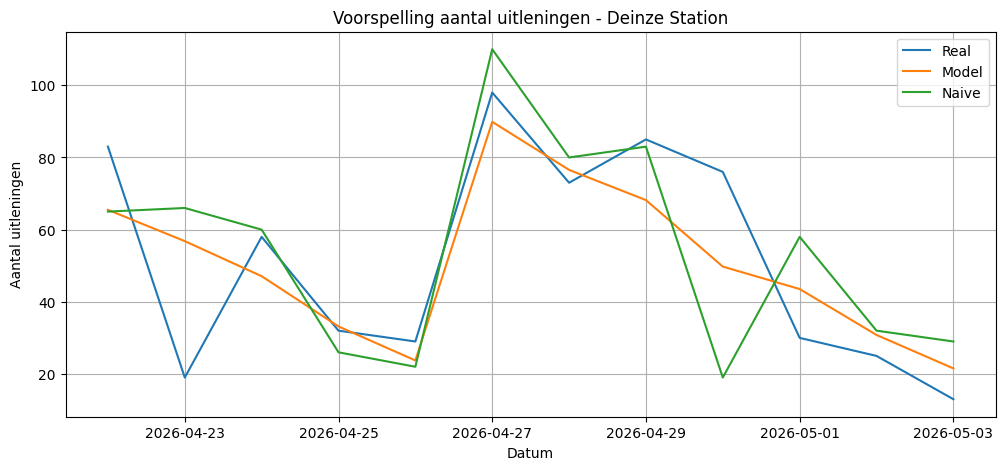

In [174]:
plt.figure(figsize=(12,5))

plt.plot(valid_test.index, valid_test["UitleningenPerDag"], label="Real")
plt.plot(valid_test.index, valid_test["Prediction"], label="Model")
plt.plot(valid_test.index, valid_test["NaiveForecast"], label="Naive")

plt.title(f"Voorspelling aantal uitleningen - {station_name}")
plt.xlabel("Datum")
plt.ylabel("Aantal uitleningen")
plt.legend()
plt.grid()

plt.show()

## Conclusie

De prestaties van de modellen worden geëvalueerd met de Mean Absolute Error (MAE):

- MAE Naïeve voorspeller: 17.42
- MAE Linear Regression model: 12.94

Hieruit blijkt dat:

- Het machine learning model duidelijk beter presteert dan de naïeve voorspeller
- De fout van het model is gemiddeld ~4.5 uitleningen per dag lager. Dit komt neer op een verbetering van ongeveer 24% ten opzichte van de naïeve voorspeller.
- Dit betekent dat het model beter in staat is om patronen in de data te capteren

**Besluit**: Het Linear Regression model is een geschikte en eenvoudige baseline voor deze tijdreeks en levert betere voorspellingen dan de naïeve aanpak.
